### 1. Importing Libraries

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from scipy.stats import norm

### 2. Load dataset and check informations 

In [2]:
# df stands for data frame
df = pd.read_csv('route_performance.csv')
df.head(5)


,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,2015,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",6.37,50.0,19,320.5
1,2018,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.92,68.0,22,539.4
2,2019,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.65,65.0,21,498.0
3,2020,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",2.21,21.0,4,45.4
4,2021,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",3.57,34.0,10,121.5


In [3]:
# data  frame shape
print(f" data frame has RowsxColumns : {df.shape}")
print('--------------------------------------------')
df.info()

 data frame has RowsxColumns : (400, 11)
--------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  400 non-null    int64  
 1   route                 400 non-null    str    
 2   origin_iata           400 non-null    str    
 3   destination_iata      400 non-null    str    
 4   distance_km           400 non-null    int64  
 5   region                400 non-null    str    
 6   main_airlines         400 non-null    str    
 7   annual_passengers_m   400 non-null    float64
 8   avg_fare_usd          400 non-null    float64
 9   weekly_frequency_est  400 non-null    int64  
 10  annual_revenue_usd_m  400 non-null    float64
dtypes: float64(3), int64(3), str(5)
memory usage: 34.5 KB


In [4]:
# checking columns to get data insights
df.columns

Index(['year', 'route', 'origin_iata', 'destination_iata', 'distance_km',
       'region', 'main_airlines', 'annual_passengers_m', 'avg_fare_usd',
       'weekly_frequency_est', 'annual_revenue_usd_m'],
      dtype='str')

In [5]:
# checking the data types
print(df.dtypes)

year                      int64
route                       str
origin_iata                 str
destination_iata            str
distance_km               int64
region                      str
main_airlines               str
annual_passengers_m     float64
avg_fare_usd            float64
weekly_frequency_est      int64
annual_revenue_usd_m    float64
dtype: object


In [6]:
print(df.isnull().count())

year                    400
route                   400
origin_iata             400
destination_iata        400
distance_km             400
region                  400
main_airlines           400
annual_passengers_m     400
avg_fare_usd            400
weekly_frequency_est    400
annual_revenue_usd_m    400
dtype: int64


### 3. Data cleaning and Preprocessing

In [7]:
# check for duplicate data
print(f'The sum of duplicates is : {df.duplicated().sum()}')



The sum of duplicates is : 0


### 4.Exploratory Data Analysis

In [8]:
# drop columns which are of categorical data that are unrelated to prediction
#df = df.drop(columns=['route','origin_iata','destination_iata','main_airlines,])
df.head(2)

,year,route,origin_iata,destination_iata,distance_km,region,main_airlines,annual_passengers_m,avg_fare_usd,weekly_frequency_est,annual_revenue_usd_m
0,2015,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",6.37,50.0,19,320.5
1,2018,Jeju-Seoul,CJU,GMP,451,Asia,"Korean Air, Asiana, JeJu Air",7.92,68.0,22,539.4


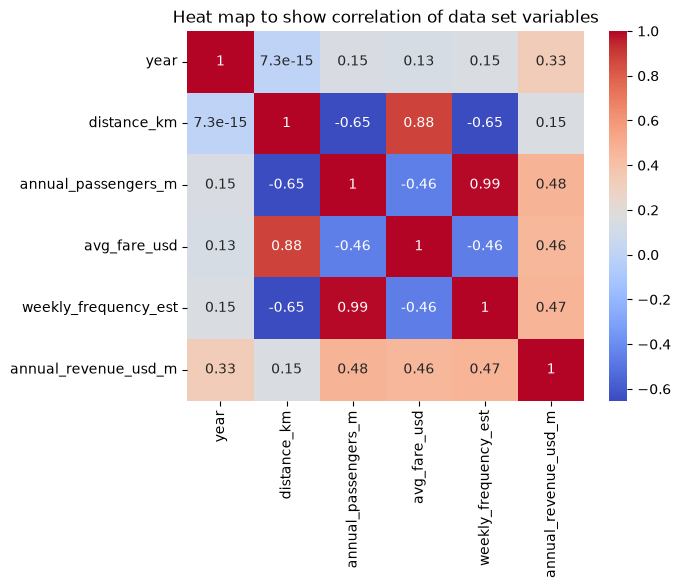

In [9]:
# checking for the correlation

plt.title('Heat map to show correlation of data set variables')
sns.heatmap( df.corr(numeric_only=True) , annot=True,cmap='coolwarm')
plt.show()

### 5. Train and  Test data

In [10]:
# select features for x and y
X = df[['distance_km' , 'region' , 'annual_passengers_m' , 'avg_fare_usd' , 'weekly_frequency_est' ]]
y = df['annual_revenue_usd_m']

# encode regional column
X = pd.get_dummies(X , columns=['region'])


In [11]:

#create a train test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)


# choose model 
model = LinearRegression()
model.fit(X_train,y_train )

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](18,)","[ -0.01, 76.75, 2.3 ,..., 83.51, 38.22,-60.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](18,)","['distance_km','annual_passengers_m','avg_fare_usd',..., 'region_North America','region_Oceania','region_Pacific']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-230.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,18
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(17)


### 6. Model prediction

In [12]:
# make prediction
y_pred = model.predict(X_test)

### 7. Model evaluation

In [25]:
# MAE stands for mean absolute error
MAE = mean_absolute_error(y_test,y_pred)

# MSE stands or mean squared error
MSE = mean_squared_error(y_test,y_pred)

# RMSE stands for root mean squared error
RMSE = root_mean_squared_error(y_test,y_pred)

# r_2_sore stands for r2_score
r_2_score = r2_score(y_test,y_pred)

# print metrics
print(f'mean absolute error : {MAE:.3}')
print(f'mean squared error : {MSE:.3}')
print(f'root mean squared error : {RMSE:.3}')
print(f'r2 score is  : {r_2_score:.4}')

mean absolute error : 97.5
mean squared error : 1.6e+04
root mean squared error : 1.27e+02
r2 score is  : 0.8511


### 8. Visualization of results

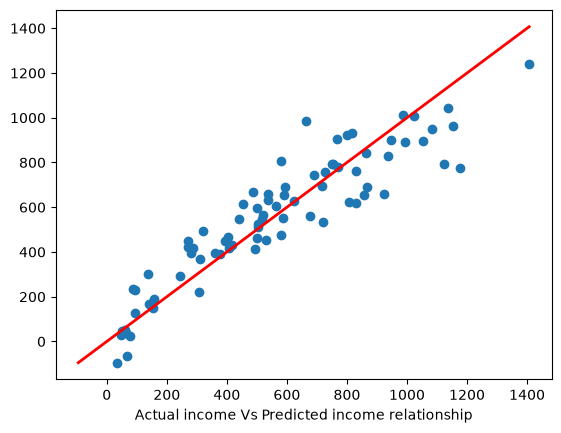

In [19]:
# Graph for actual values Vs predicted values
plt.xlabel('Actual income Vs Predicted income relationship')
plt.scatter(y_test,y_pred)

# draw a reference line
min_val = min(y_test.min(),y_pred.min())
max_val = max(y_test.max(),y_pred.max())
plt.plot([min_val,max_val],[min_val,max_val],'r-',linewidth = 2)


plt.show()

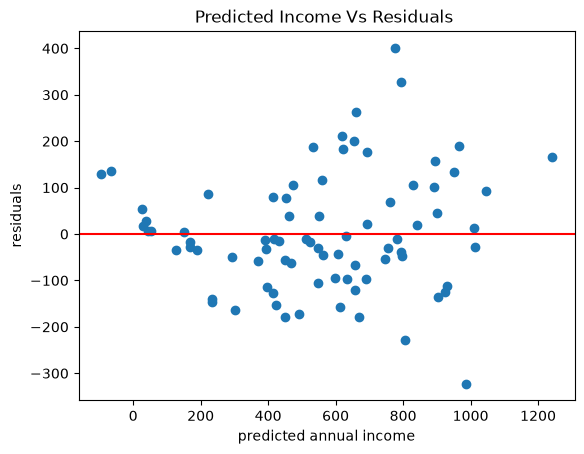

In [20]:
# residual plot
residuals = y_test - y_pred

plt.title('Predicted Income Vs Residuals ')
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red')
plt.xlabel('predicted annual income')
plt.ylabel('residuals')
plt.show()

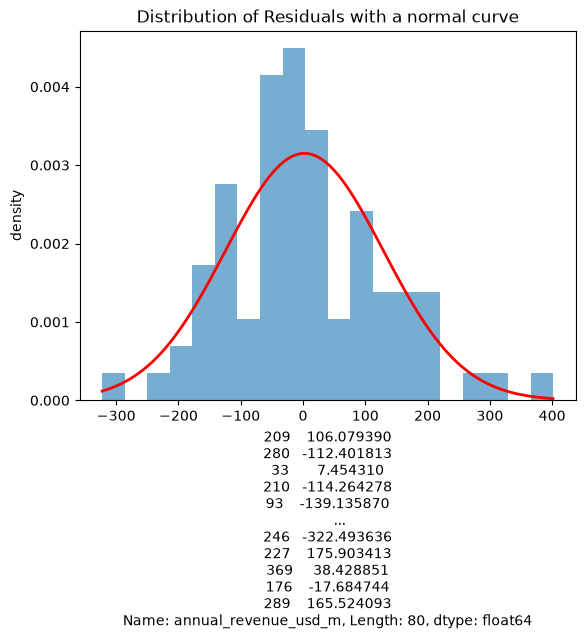

In [23]:
# Histogram of residuals and standard deviation
plt.title('Distribution of Residuals with a normal curve')
plt.hist( residuals , bins = 20 , density = True , alpha = 0.6 )

# calculating mean and standard deviation
mu , sigma = norm.fit(residuals)

#plot a normal distribution curve
x = np.linspace( residuals.min() , residuals.max() , 100 )
y = norm.pdf( x , mu , sigma )
plt.plot(x , y , 'r-' , linewidth = 2 )

plt.xlabel(residuals)
plt.ylabel('density')
plt.show()